In [ ]:
# Execute first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

# Imports

In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from scdisentangle.train.tools import get_trainer, set_seed

In [2]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

In [ ]:
# Merge subtypes for cleaner visualization

In [3]:
ctype_rename_map = {
    'Imm_Macrophage_2': 'Imm_Macrophage',
    'Imm_Macrophage_3': 'Imm_Macrophage',
    'Imm_Macrophage_1b': 'Imm_Macrophage',
    'Imm_Macrophage_1a_vcam': 'Imm_Macrophage',
    'Str_SmoothMuscle_1':'Str_SmoothMuscle',
    'Str_SmoothMuscle_2':'Str_SmoothMuscle',
    'Str_Mesenchymal_1':'Str_Mesenchymal',
    'Str_Mesenchymal_2':'Str_Mesenchymal', 
}

In [4]:
ctype_colors = {
 'Epi_Basal_1': '#f4a261',
 'Str_Endothelium_Vascular': '#e377c2',
 'Str_SmoothMuscle': '#aa40fc',
 'Str_Glial': '#8c564b',
 'Epi_Luminal_1': '#d62728',
 'Str_Mesenchymal': '#b5bd61',
 'Epi_Luminal_3Foxi1': '#E69F00',
 'Str_Endothelium_Lymphatic': '#aec7e8',
 'Epi_Luminal_2Psca': '#264653',
 'Imm_DC': '#c5b0d5',
 'Imm_Macrophage': '#c49c94',
 'Imm_NK': '#f7b6d2',
 'Imm_B': '#dbdb8d',
 'Imm_Tcell': '#9edae5',
}

# Set seed

In [5]:
seed_nb = 42
set_seed(seed_nb)

ic| 'Setting seed to', seed: 42


# Get Trainer

In [6]:
yaml_path = 'configs/prostate_disentangle.yaml'

In [ ]:
trainer = get_trainer(yaml_path, wandb_log=False, seed_nb=seed_nb)

# Train

In [8]:
trainer.train()

# Load best weights

In [9]:
weights_path = 'disentangle_weights/MIG_BINNED_dis_latent_stack_time_train'
trainer.load_weights(weights_path)

Loading weights from disentangle_weights/MIG_BINNED_dis_latent_stack_time_train


# Get Latent

In [10]:
counterfactual_dict = {'time': 'T00'}

# Inference

In [11]:
# Filter

ctypes_to_filter = [
    'Epi_SV_Ionocyte', 'Epi_SV_Luminal', 'Epi_SV_Basal',
    'SymDoublet_Epi_Imm', 'SymDoublet_Str_Epi', 'SymDoublet_Str_Imm'
]

adata_inp = trainer.dataset.data[~trainer.dataset.data.obs['predType'].isin(ctypes_to_filter)].copy()

In [12]:
adata = trainer.predict(
    adata_inp.copy(), 
    counterfactual_dict=counterfactual_dict, 
    bs=256
)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 322/322 [00:02<00:00, 133.56it/s]


In [13]:
adata

AnnData object with n_obs × n_vars = 82193 × 5027
    obs: 'barcode', 'barcodeInt', 'batchID', 'highLevelPred', 'highLevelPredAmbig', 'predType', 'predTypeAmbig', 'predTypeInt', 'predTypeIntAmbig', 'time', 'n_counts', 'placeholder', 'sc_cell_ids', 'cell_ids', 'split_anndata', 'time_org', 'time_pred'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep'
    uns: 'rank_genes_groups_time'
    obsm: 'dis_latent_stack', 'cat_latent_stack', 'cat_latent_stack_collapse', 'map_latent_summed_collapse', 'map_latent_summed'
    layers: 'counts'

In [14]:
adata.X.max(), adata.X.min()

(10113.892, 0.0)

# Normalize

In [15]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [16]:
# Rename cell types
adata.obs["predType"] = (
    adata.obs["predType"]
    .map(ctype_rename_map)
    .fillna(adata.obs["predType"])
)

# Disentangled latent

In [17]:
disentangled_latent = adata.obsm['dis_latent_stack']

In [18]:
adata_dis = sc.AnnData(
    X=disentangled_latent, 
    obs=adata.obs.copy()
)

# UMAP

In [19]:
sc.pp.neighbors(adata_dis)
sc.tl.umap(adata_dis)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
2026-03-04 22:42:16.478441: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-04 22:42:16.489146: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-04 22:42:16.489168: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-04 22:42:16.992176: W tensorflow/compiler/tf

In [20]:
import os 

In [21]:
save_path = f'{FIG_ROOT}/Prostate/Disentangle'
os.makedirs(save_path, exist_ok=True)

In [22]:
import local_tools as lt

In [23]:
adata_dis = lt.rename_time_points(
    adata_dis, 
    obs_name='time_org', 
    mapping_type='full'
)

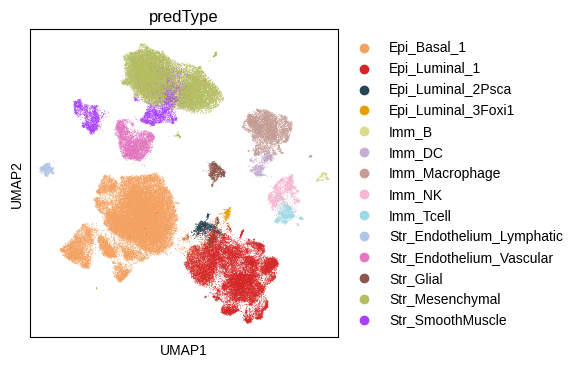

In [24]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(
    adata_dis, 
    color=['predType'],
    show=False,
    ax=ax,
    palette=ctype_colors
)
ax.set_aspect('equal')
ax.set_box_aspect(1)
for coll in ax.collections:  # iterates over plotted points
    coll.set_rasterized(True)
    
plt.savefig(f'{save_path}/umap_disentangled_predType.png', dpi=400)
plt.savefig(f'{save_path}/umap_disentangled_predType.svg', dpi=400)

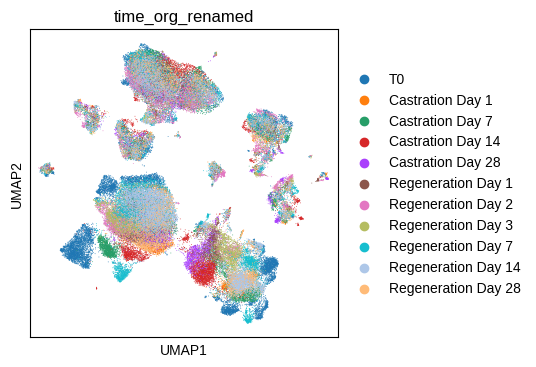

In [25]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sc.pl.umap(
    adata_dis, 
    color=['time_org_renamed'],
    show=False,
    ax=ax,
)
ax.set_aspect('equal')
ax.set_box_aspect(1)
for coll in ax.collections:  # iterates over plotted points
    coll.set_rasterized(True)
    
plt.savefig(f'{save_path}/umap_disentangled_time.png', dpi=400)
plt.savefig(f'{save_path}/umap_disentangled_time.svg', dpi=400)

# PCA of l1 cells

In [26]:
l1_cells = adata_dis[adata_dis.obs['predType'] == 'Epi_Luminal_1'].copy()

In [27]:
sc.pp.pca(l1_cells)

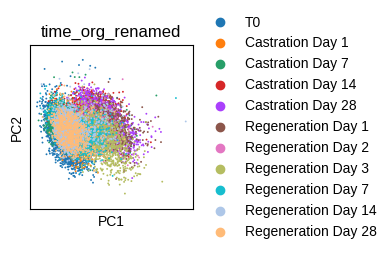

In [28]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.pca(
    l1_cells, 
    color=['time_org_renamed'],
    show=False,
    ax=ax
)
ax.set_aspect('equal')
ax.set_box_aspect(1)
for coll in ax.collections:  # iterates over plotted points
    coll.set_rasterized(True)
    
plt.tight_layout()
plt.savefig(f'{save_path}/pca_disentangled_l1.png', dpi=400)
plt.savefig(f'{save_path}/pca_disentangled_l1.svg', dpi=400)

# Original data

In [29]:
adata_inp.X.max(), adata_inp.X.min()

(15165.0, 0.0)

In [30]:
adata_inp

AnnData object with n_obs × n_vars = 82193 × 5027
    obs: 'barcode', 'barcodeInt', 'batchID', 'highLevelPred', 'highLevelPredAmbig', 'predType', 'predTypeAmbig', 'predTypeInt', 'predTypeIntAmbig', 'time', 'n_counts', 'placeholder', 'sc_cell_ids', 'cell_ids', 'split_anndata'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep'
    uns: 'rank_genes_groups_time'
    layers: 'counts'

In [31]:
sc.pp.normalize_total(adata_inp)
sc.pp.log1p(adata_inp)

In [32]:
# rename cell types
# Rename cell types
adata_inp.obs["predType"] = (
    adata_inp.obs["predType"]
    .map(ctype_rename_map)
    .fillna(adata_inp.obs["predType"])
)

In [33]:
# Umap

In [34]:
sc.pp.neighbors(adata_inp)
sc.tl.umap(adata_inp)

/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/scanpy/neighbors/__init__.py:586: UserWarning: You’re trying to run this on 5027 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  X = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


In [35]:
adata_inp = lt.rename_time_points(adata_inp, obs_name='time', mapping_type='full')

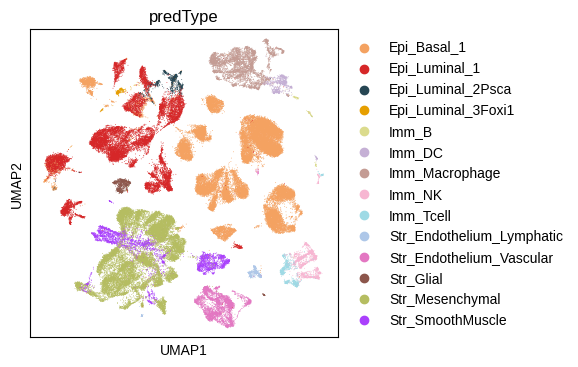

In [36]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(
    adata_inp, 
    color=['predType'],
    show=False,
    ax=ax,
    palette=ctype_colors
)
ax.set_aspect('equal')
ax.set_box_aspect(1)
for coll in ax.collections:  # iterates over plotted points
    coll.set_rasterized(True)
    
plt.savefig(f'{save_path}/umap_original_predType.png', dpi=400, bbox_inches='tight')
plt.savefig(f'{save_path}/umap_original_predType.svg', dpi=400, bbox_inches='tight')

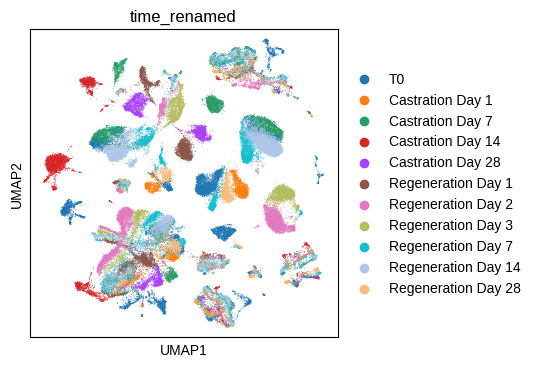

In [37]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.umap(
    adata_inp, 
    color=['time_renamed'],
    show=False,
    ax=ax
)
ax.set_aspect('equal')
ax.set_box_aspect(1)
for coll in ax.collections:  
    coll.set_rasterized(True)
    
plt.savefig(f'{save_path}/umap_original_time.png', dpi=400)
plt.savefig(f'{save_path}/umap_original_time.svg', dpi=400)

In [38]:
# 

In [39]:
# PCA of l1 cells

In [40]:
org_l1_cells = adata_inp[adata_inp.obs['predType'] == 'Epi_Luminal_1'].copy()
sc.pp.pca(org_l1_cells)

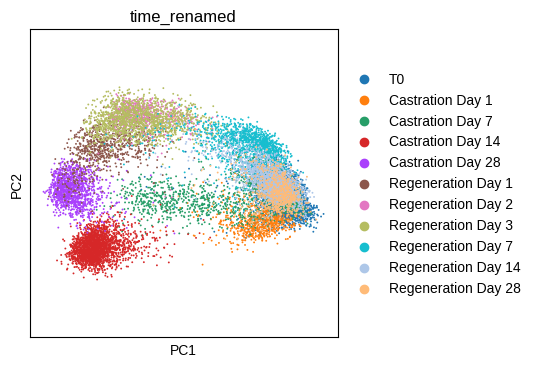

In [41]:
fig, ax = plt.subplots(figsize=(4, 4))
sc.pl.pca(
    org_l1_cells, 
    color=['time_renamed'],
    show=False,
    ax=ax
)
ax.set_aspect('equal')
ax.set_box_aspect(1)
for coll in ax.collections: 
    coll.set_rasterized(True)
    
plt.savefig(f'{save_path}/pca_original_l1.png', dpi=400)
plt.savefig(f'{save_path}/pca_original_l1.svg', dpi=400)

In [42]:
cats = adata_inp.obs['time_renamed'].cat.categories
colors = adata_inp.uns['time_renamed_colors']
palette = dict(zip(cats, colors))

In [43]:
palette

{'T0': '#1f77b4',
 'Castration Day 1': '#ff7f0e',
 'Castration Day 7': '#279e68',
 'Castration Day 14': '#d62728',
 'Castration Day 28': '#aa40fc',
 'Regeneration Day 1': '#8c564b',
 'Regeneration Day 2': '#e377c2',
 'Regeneration Day 3': '#b5bd61',
 'Regeneration Day 7': '#17becf',
 'Regeneration Day 14': '#aec7e8',
 'Regeneration Day 28': '#ffbb78'}

# Export legend

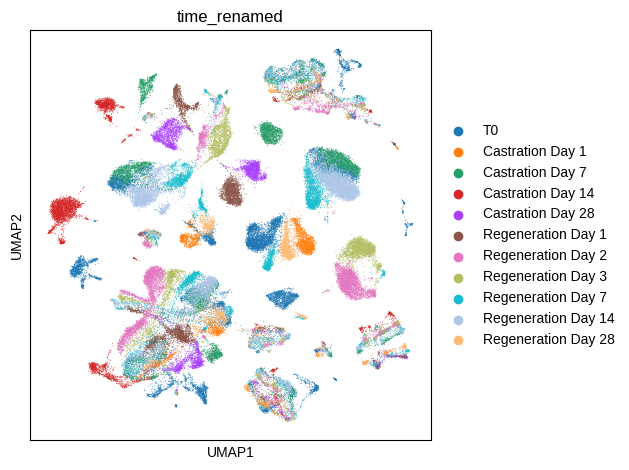

In [44]:
sc.pl.umap(
    adata_inp, 
    color=['time_renamed'],
    show=False,
)

plt.tight_layout()
plt.savefig(f'{save_path}/legend_time.png', dpi=400, bbox_inches='tight')
plt.savefig(f'{save_path}/legend_time.svg', dpi=400, bbox_inches='tight')

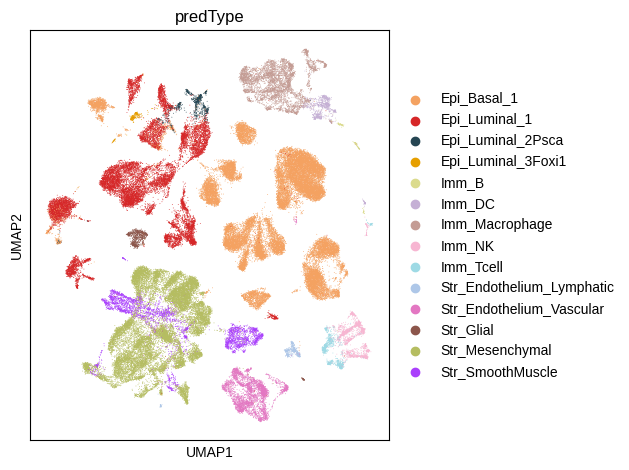

In [45]:
sc.pl.umap(
    adata_inp, 
    color=['predType'],
    show=False,
)
plt.tight_layout()
plt.savefig(f'{save_path}/legend_predType.png', dpi=400, bbox_inches='tight')
plt.savefig(f'{save_path}/legend_predType.svg', dpi=400, bbox_inches='tight')

In [46]:
assert adata_inp.obs['predType'].unique().tolist() == adata_dis.obs['predType'].unique().tolist()

In [47]:
adata_inp

AnnData object with n_obs × n_vars = 82193 × 5027
    obs: 'barcode', 'barcodeInt', 'batchID', 'highLevelPred', 'highLevelPredAmbig', 'predType', 'predTypeAmbig', 'predTypeInt', 'predTypeIntAmbig', 'time', 'n_counts', 'placeholder', 'sc_cell_ids', 'cell_ids', 'split_anndata', 'time_renamed'
    var: 'gene_ids', 'feature_types', 'genome', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'keep'
    uns: 'rank_genes_groups_time', 'log1p', 'pca', 'neighbors', 'umap', 'predType_colors', 'time_renamed_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'